## IMAGE LAB

В данной лабораторной работе я обучил модель на фотографиях разной городской застройки: европейский старый город, латинские фавеллы, азисатские улицы, небоскребы. Модель училась отгадывать их по фото

Перед обучением я прогнал фотографии в приложении Tonfotos чтобы удалить скачавшиеся дубликаты

In [1]:
import os
import shutil
import time
import matplotlib.pyplot as plt
import umap.umap_ as umap
from torch.nn import CrossEntropyLoss
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from torchvision.models import resnet18
import torch
import torch.nn as nn
from PIL import Image

**Подготовка фотографий**

Разделение на train/test/val

In [2]:
def new_dir(name, all_continent_dir_path, continent, imgs):
    for img in imgs:
        curr_path = os.path.join(all_continent_dir_path, img)
        new_path = f"streets/{name}/{continent}/{img}"
        shutil.copy(curr_path, new_path)


for dir in os.listdir("streets/all"):
    if dir == ".DS_Store":
        continue

    continent_dir_path = os.path.join("streets/all", dir)
    os.makedirs(f"streets/train/{dir}", exist_ok=True)
    os.makedirs(f"streets/test/{dir}", exist_ok=True)
    os.makedirs(f"streets/val/{dir}", exist_ok=True)

    imgs = os.listdir(continent_dir_path)

    train_imgs, test_val_imgs = train_test_split(imgs, train_size=0.8, random_state=42, shuffle=True)
    test_imgs, val_imgs = train_test_split(test_val_imgs, train_size=0.5, random_state=42, shuffle=True)

    new_dir("train", continent_dir_path, dir, train_imgs)
    new_dir("test", continent_dir_path, dir, test_imgs)
    new_dir("val", continent_dir_path, dir, val_imgs)


In [53]:
streets = ["europe old town", "asia", "us skyscrapers", "favelas"]

for street in streets:
    path = os.path.join("streets/all", street)
    imgs = []
    for img in os.listdir(path):
        imgs.append(img)

    print(f"{street}: {len(imgs)} photo")

europe old town: 1085 photo
asia: 1003 photo
us skyscrapers: 1050 photo
favelas: 1004 photo


In [4]:
NUM_EPOCHES = 30
NUM_CLASSES = 4
DROPOUT = 0.3
BATCH_SIZE = 16
DEVICE = "mps" if torch.mps.is_available() else "cpu"

In [67]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = ImageFolder("streets/train", transform=train_transform)
test_dataset = ImageFolder("streets/test", transform=test_transform)
val_dataset = ImageFolder("streets/val", transform=val_transforms)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

**CNN**

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )


        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(128),
            nn.Dropout(dropout),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def get_penultimate_embed(self, x):
        x = self.layers(x)
        x = self.fc[0](x)
        x = self.fc[1](x)
        return x

    def forward(self, x):
        x = self.layers(x)
        x = self.fc(x)
        return x


In [7]:
cnn_model = CNN(num_classes=NUM_CLASSES, dropout=DROPOUT)

loss_fn = CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
cnn_model.to(DEVICE)

CNN(
  (layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0

Подсчёт метрик для валидации и тестов

In [8]:
def count_metrics(model, dataloader, device, loss_fn):
    model.eval()

    total_loss = 0
    true_preds = 0
    count_preds = 0

    with torch.no_grad():
        for img, target in dataloader:
            img, target = img.to(device), target.to(device)

            logits = model(img)
            preds = logits.argmax(1)
            true_preds += (preds == target).sum().item()
            count_preds += target.size(0)

            loss = loss_fn(logits, target)
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        avg_acc = true_preds / count_preds
        return avg_loss, avg_acc

Одна тренировочная эпоха

In [9]:
def train_epoch(model, dataloader, device, loss_fn, optimizer):
    model.train()

    total_loss = 0
    true_preds = 0
    count_preds = 0

    for img, target in dataloader:
        img, target = img.to(device), target.to(device)
        optimizer.zero_grad()
        logits = model(img)

        preds = logits.argmax(1)
        true_preds += (preds == target).sum().item()
        count_preds += target.size(0)

        loss = loss_fn(logits, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    avg_acc = true_preds / count_preds
    return avg_loss, avg_acc

In [10]:
def learning_cycles(model, num_epoches, device, train_dataloader, val_dataloader, loss_fn, optimizer):
    train_loss = []
    train_acc = []
    val_loss = []
    val_acc = []

    for epoche in range(1, num_epoches + 1):
        avg_train_loss, avg_train_acc = train_epoch(model, train_dataloader, device, loss_fn, optimizer=optimizer)
        train_loss.append(avg_train_loss)
        train_acc.append(avg_train_acc)

        avg_val_loss, avg_val_acc = count_metrics(model, val_dataloader, device, loss_fn)
        val_loss.append(avg_val_loss)
        val_acc.append(avg_val_acc)

        print(f"Epoch {epoche}/{num_epoches}")
        print(f"\tavg_train_loss = {avg_train_loss:.4f}")
        print(f"\tavg_train_acc = {avg_train_acc:.4f}")
        print(f"\tavg_val_loss = {avg_val_loss:.4f}")
        print(f"\tavg_val_acc = {avg_val_acc:.4f}")

    return train_loss, train_acc, val_loss, val_acc

Обучение CNN

In [11]:
start = time.time()
cnn_train_loss, cnn_train_acc, cnn_val_loss, cnn_val_acc = learning_cycles(cnn_model, NUM_EPOCHES, DEVICE,
                                                                           train_dataloader, val_dataloader, loss_fn,
                                                                           cnn_optimizer)
end = time.time()

cnn_time = end - start
cnn_minutes = cnn_time // 60
cnn_seconds = cnn_time - cnn_time // 60 * 60
print(f"CNN Time: {int(cnn_minutes)} min {int(cnn_seconds)} sec")

Epoch 1/30
	avg_train_loss = 1.9618
	avg_train_acc = 0.4208
	avg_val_loss = 1.0913
	avg_val_acc = 0.4856
Epoch 2/30
	avg_train_loss = 1.1290
	avg_train_acc = 0.4652
	avg_val_loss = 1.0695
	avg_val_acc = 0.4760
Epoch 3/30
	avg_train_loss = 1.0825
	avg_train_acc = 0.4716
	avg_val_loss = 1.0610
	avg_val_acc = 0.5024
Epoch 4/30
	avg_train_loss = 1.0418
	avg_train_acc = 0.5012
	avg_val_loss = 1.0197
	avg_val_acc = 0.5168
Epoch 5/30
	avg_train_loss = 1.0307
	avg_train_acc = 0.5118
	avg_val_loss = 1.0278
	avg_val_acc = 0.5120
Epoch 6/30
	avg_train_loss = 1.0076
	avg_train_acc = 0.5287
	avg_val_loss = 1.0186
	avg_val_acc = 0.5144
Epoch 7/30
	avg_train_loss = 0.9944
	avg_train_acc = 0.5166
	avg_val_loss = 0.9610
	avg_val_acc = 0.5457
Epoch 8/30
	avg_train_loss = 0.9649
	avg_train_acc = 0.5345
	avg_val_loss = 0.9703
	avg_val_acc = 0.5505
Epoch 9/30
	avg_train_loss = 0.9638
	avg_train_acc = 0.5402
	avg_val_loss = 0.9378
	avg_val_acc = 0.5745
Epoch 10/30
	avg_train_loss = 0.9370
	avg_train_acc = 0

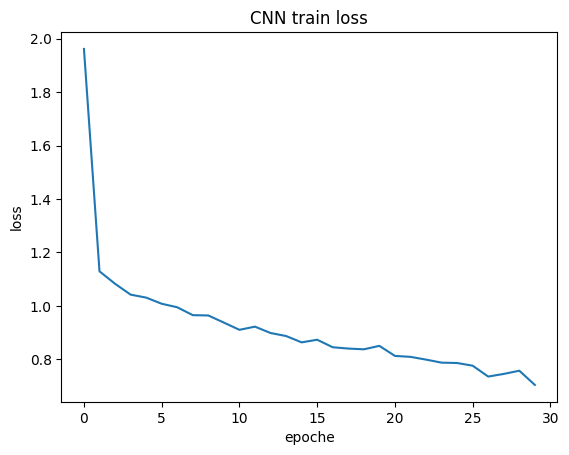

In [12]:
plt.plot(cnn_train_loss)
plt.title("CNN train loss")
plt.xlabel("epoche")
plt.ylabel("loss")
plt.show()

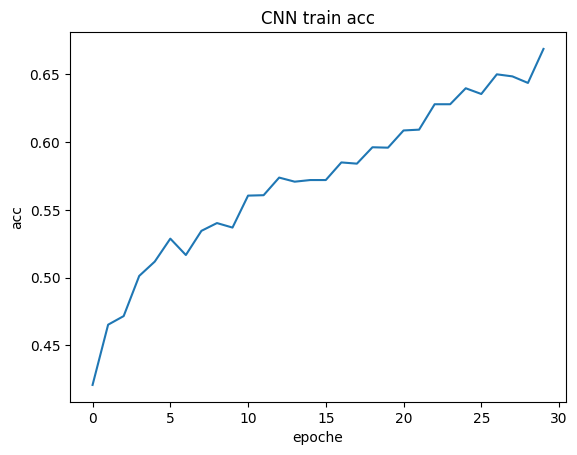

In [13]:
plt.plot(cnn_train_acc)
plt.title("CNN train acc")
plt.xlabel("epoche")
plt.ylabel("acc")
plt.show()

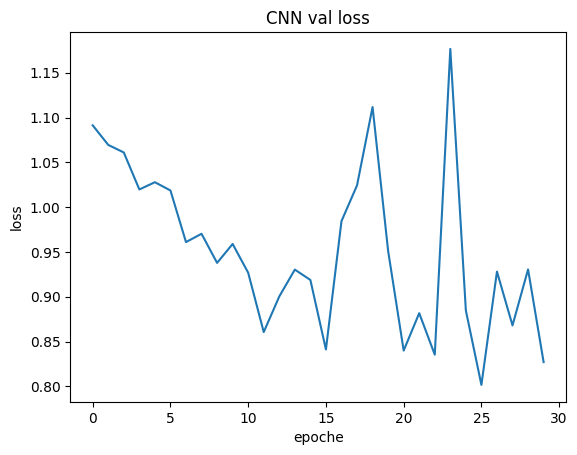

In [14]:
plt.plot(cnn_val_loss)
plt.title("CNN val loss")
plt.xlabel("epoche")
plt.ylabel("loss")
plt.show()

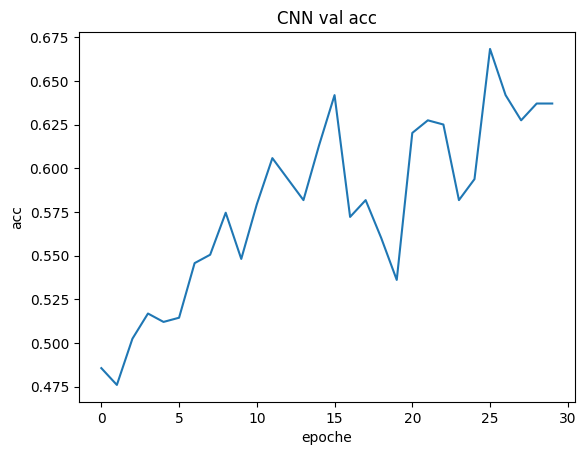

In [15]:
plt.plot(cnn_val_acc)
plt.title("CNN val acc")
plt.xlabel("epoche")
plt.ylabel("acc")
plt.show()

Проверка CNN на тестовых данных

In [16]:
_, cnn_test_acc = count_metrics(cnn_model, test_dataloader, DEVICE, loss_fn)
print(f"test cnn acc: {cnn_test_acc}")

test cnn acc: 0.6368038740920097


Эмбеддинги

In [17]:
cnn_embeds = []
cnn_targets = []

cnn_model.eval()
with torch.no_grad():
    for img, target in test_dataloader:
        img, target = img.to(DEVICE), target.to(DEVICE)

        embed = cnn_model.get_penultimate_embed(img)

        cnn_embeds.append(embed)
        cnn_targets.append(target)

embeds = torch.cat(cnn_embeds).cpu()
targets = torch.cat(cnn_targets).cpu()

UMAP

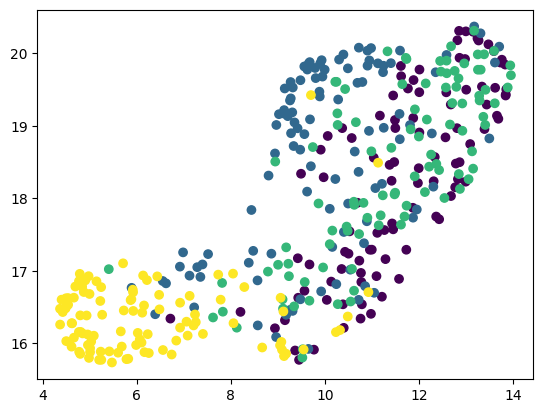

In [18]:
ump = umap.UMAP(n_components=2)
ump = ump.fit_transform(embeds)
plt.scatter(ump[:, 0], ump[:, 1], c=targets)
plt.show()

**ResNet**

In [28]:
weights = "models/resnet18-f37072fd.pth"
load = torch.load(weights, map_location="mps")

resnet = resnet18(weights=None)
resnet.load_state_dict(load)

for params in resnet.parameters():
    params.requires_grad = False

resnet.fc = nn.Sequential(
    nn.Linear(512, 128),
    nn.Dropout(DROPOUT),
    nn.ReLU(),
    nn.Linear(128, NUM_CLASSES)
)

resnet_optimizer = torch.optim.Adam(resnet.parameters(), lr=0.001)
resnet.to(DEVICE)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [29]:
start = time.time()
resnet_train_loss, resnet_train_acc, resnet_val_loss, resnet_val_acc = learning_cycles(resnet, NUM_EPOCHES, DEVICE,
                                                                                       train_dataloader, val_dataloader,
                                                                                       loss_fn, resnet_optimizer)
end = time.time()

resnet_time = end - start
resnet_minutes = resnet_time // 60
resnet_seconds = resnet_time - resnet_time // 60 * 60
print(f"CNN Time: {int(resnet_minutes)} min {int(resnet_seconds)} sec")

Epoch 1/30
	avg_train_loss = 0.8559
	avg_train_acc = 0.6485
	avg_val_loss = 0.6062
	avg_val_acc = 0.7428
Epoch 2/30
	avg_train_loss = 0.6710
	avg_train_acc = 0.7414
	avg_val_loss = 0.6106
	avg_val_acc = 0.7620
Epoch 3/30
	avg_train_loss = 0.6212
	avg_train_acc = 0.7411
	avg_val_loss = 0.5599
	avg_val_acc = 0.7692
Epoch 4/30
	avg_train_loss = 0.6240
	avg_train_acc = 0.7508
	avg_val_loss = 0.5702
	avg_val_acc = 0.7476
Epoch 5/30
	avg_train_loss = 0.6149
	avg_train_acc = 0.7568
	avg_val_loss = 0.5592
	avg_val_acc = 0.7524
Epoch 6/30
	avg_train_loss = 0.5836
	avg_train_acc = 0.7713
	avg_val_loss = 0.5592
	avg_val_acc = 0.7548
Epoch 7/30
	avg_train_loss = 0.5790
	avg_train_acc = 0.7765
	avg_val_loss = 0.5271
	avg_val_acc = 0.7668
Epoch 8/30
	avg_train_loss = 0.5515
	avg_train_acc = 0.7737
	avg_val_loss = 0.5500
	avg_val_acc = 0.7500
Epoch 9/30
	avg_train_loss = 0.5785
	avg_train_acc = 0.7677
	avg_val_loss = 0.5127
	avg_val_acc = 0.7524
Epoch 10/30
	avg_train_loss = 0.5560
	avg_train_acc = 0

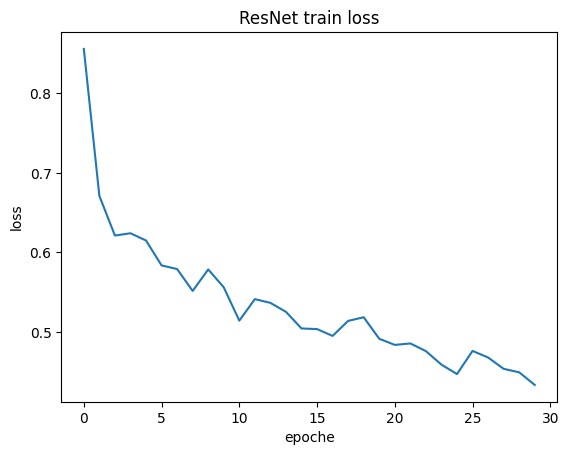

In [30]:
plt.plot(resnet_train_loss)
plt.title("ResNet train loss")
plt.xlabel("epoche")
plt.ylabel("loss")
plt.show()

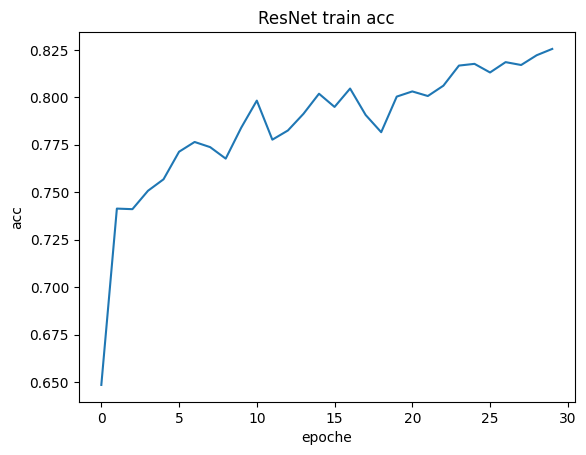

In [31]:
plt.plot(resnet_train_acc)
plt.title("ResNet train acc")
plt.xlabel("epoche")
plt.ylabel("acc")
plt.show()

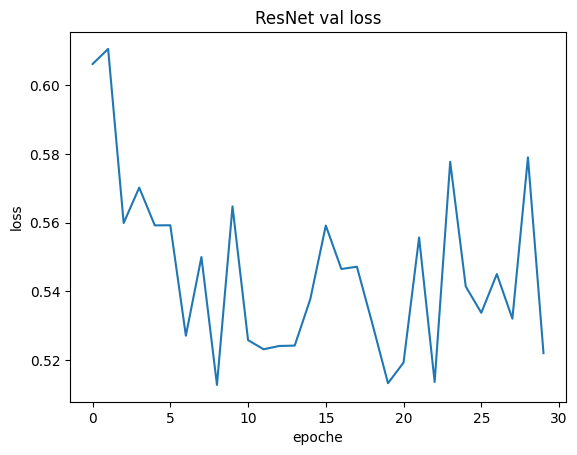

In [32]:
plt.plot(resnet_val_loss)
plt.title("ResNet val loss")
plt.xlabel("epoche")
plt.ylabel("loss")
plt.show()

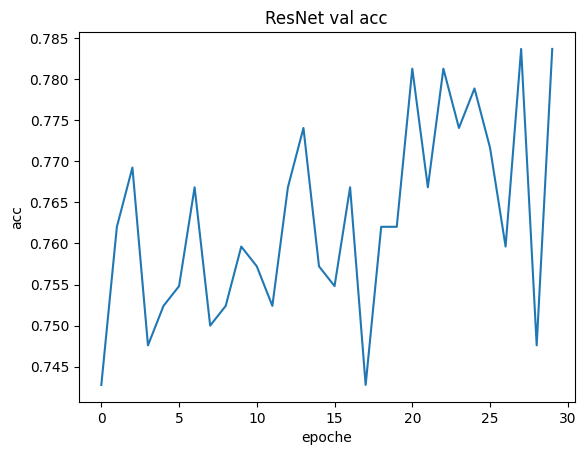

In [33]:
plt.plot(resnet_val_acc)
plt.title("ResNet val acc")
plt.xlabel("epoche")
plt.ylabel("acc")
plt.show()

Проверка ResNet на тестовых данных

In [34]:
_, resnet_test_acc = count_metrics(resnet, test_dataloader, DEVICE, loss_fn)
print(f"test resnet acc: {resnet_test_acc}")

test resnet acc: 0.7530266343825666


**Сравнение CNN и ResNet**

In [35]:
print("Время обучения")
print(f"\tCNN:    {int(cnn_minutes)} min {int(cnn_seconds)} sec")
print(f"\tResNet: {int(resnet_minutes)} min {int(resnet_seconds)} sec")

print("Accuracy")
print(f"\tCNN:    {cnn_test_acc:.2f}")
print(f"\tResNet: {resnet_test_acc:.2f}")

Время обучения
	CNN:    18 min 37 sec
	ResNet: 14 min 40 sec
Accuracy
	CNN:    0.64
	ResNet: 0.75


In [64]:
def predict_cnn(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    tensor = tensor.to(DEVICE)

    cnn_model.eval()
    with torch.no_grad():
        logist = cnn_model(tensor)
        pred = logist.argmax(1).item()

    street = train_dataset.classes[pred]

    return street

**Примеры**

europe old town


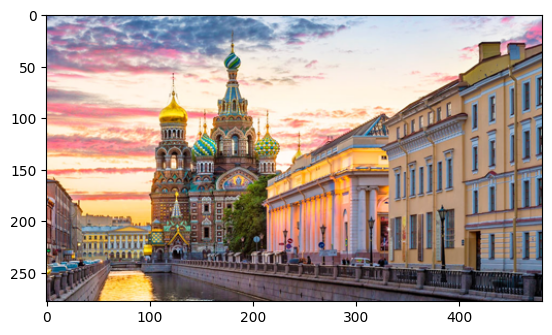

In [66]:
img = Image.open("templates/img1.png")
plt.imshow(img)
print(predict_cnn("templates/img1.png"))

asia


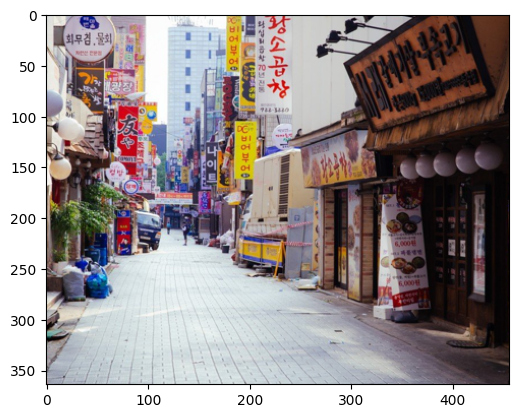

In [43]:
img = Image.open("templates/img2.png")
plt.imshow(img)
print(predict_cnn("templates/img2.png"))

favelas


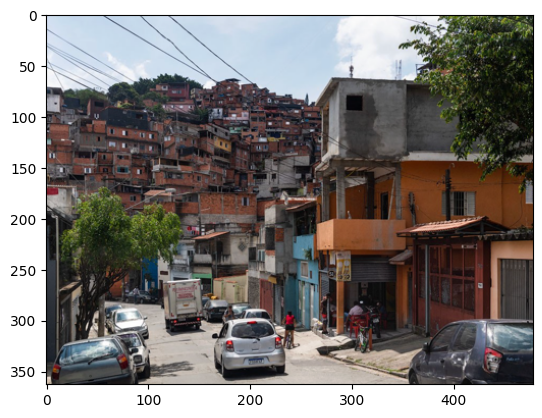

In [44]:
img = Image.open("templates/img3.png")
plt.imshow(img)
print(predict_cnn("templates/img3.png"))

us skyscrapers


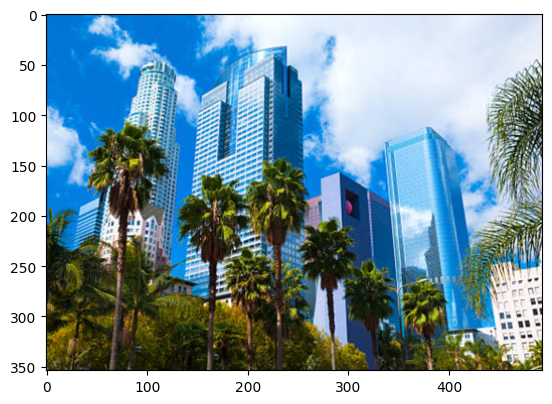

In [47]:
img = Image.open("templates/img4.png")
plt.imshow(img)
print(predict_cnn("templates/img4.png"))